In [1]:
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm  # for progress bar
from torch.cuda.amp import GradScaler, autocast
from datetime import datetime

from TtoGmodel_10 import TextToGraphTransformer

In [2]:
from Circuits import Circuits
circuits= Circuits()

Loading dataset files...
Loaded dataset files successfully.


In [3]:
print(circuits.component_lists[0])
print(circuits.graphs[0])

['VDD', 'VSS', 'VIN1', 'NM1', 'NM1_D', 'NM1_G', 'NM1_S', 'NM1_B']
[[0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 1 1 1 1]
 [1 0 0 1 0 1 0 0]
 [1 0 0 1 1 0 0 0]
 [0 0 1 1 0 0 0 0]
 [0 1 0 1 0 0 0 0]]


In [4]:
def collate_fn(batch):
    seqs, mats = zip(*batch)

    # Convert sequences to torch tensors
    seqs = [torch.tensor(seq, dtype=torch.long) for seq in seqs]

    # Convert adjacency matrices (NumPy -> PyTorch)
    mats = [torch.tensor(mat, dtype=torch.float32) for mat in mats]

    # Get max sizes
    max_seq_len = max(len(seq) for seq in seqs)
    max_nodes = max(mat.size(0) for mat in mats)

    # Pad sequences
    padded_seqs = torch.stack([
        F.pad(seq, (0, max_seq_len - len(seq)), value=0)
        for seq in seqs
    ])

    # Pad adjacency matrices
    padded_mats = torch.stack([
        F.pad(mat, (0, max_nodes - mat.size(1), 0, max_nodes - mat.size(0)), value=0)
        for mat in mats
    ])

    seq_lengths = torch.tensor([len(seq) for seq in seqs])

    return padded_seqs, padded_mats, seq_lengths


In [5]:
dataset = list(zip(circuits.component_indices, circuits.graphs))
loader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)

from sklearn.model_selection import train_test_split
import torch

# Assuming 'dataset' is already created as:
# dataset = list(zip(circuits.component_indices, circuits.graphs))

# 80% Train, 20% Test split
train_data, test_data = train_test_split(dataset, test_size=0.1, random_state=42)

# Create DataLoaders
train_loader = torch.utils.data.DataLoader(
    train_data,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = torch.utils.data.DataLoader(
    test_data,
    batch_size=16,
    shuffle=False,  # typically don't shuffle test data
    collate_fn=collate_fn
)


In [6]:
print(circuits.component_indices[0])
print(circuits.graphs[0])


[158, 783, 72, 47, 359, 216, 111, 20]
[[0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 1 1 1 1]
 [1 0 0 1 0 1 0 0]
 [1 0 0 1 1 0 0 0]
 [0 0 1 1 0 0 0 0]
 [0 1 0 1 0 0 0 0]]


In [7]:
# Initialize model parameters
vocab_size = len(circuits.vocab)  # Number of unique components
embedding_dim = 128
hidden_dim = 256
num_heads = 8
num_layers = 4
dropout = 0.1

# Initialize the model
model = TextToGraphTransformer(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    num_heads=num_heads,
    num_layers=num_layers,
    dropout=dropout
)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

TextToGraphTransformer(
  (embedding): Embedding(892, 128, padding_idx=0)
  (positional_encoding): SinusoidalPositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (edge_mlp): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): R

In [8]:
from sklearn.model_selection import train_test_split
import torch

# Assuming 'dataset' is already created as:
# dataset = list(zip(circuits.component_indices, circuits.graphs))

# 80% Train, 20% Test split
train_data, test_data = train_test_split(dataset, test_size=0.1, random_state=42)

# Create DataLoaders
train_loader = torch.utils.data.DataLoader(
    train_data,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = torch.utils.data.DataLoader(
    test_data,
    batch_size=16,
    shuffle=False,  # typically don't shuffle test data
    collate_fn=collate_fn
)


In [9]:
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence
from torch.cuda.amp import autocast, GradScaler


PAD_TOKEN_ID = 0
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()
scaler = GradScaler()

num_epochs = 30
save_every = 10

train_losses = []
test_losses = []

for epoch in range(1, num_epochs + 1):
    # ========== Training ==========
    model.train()
    total_train_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch} [Training]", leave=False)

    for input_seqs, adj_mats, seq_lengths in progress_bar:
        input_seqs = input_seqs.to(device, non_blocking=True)
        adj_mats = adj_mats.to(device, non_blocking=True)
        seq_lengths = seq_lengths.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast():
            seq_mask = (input_seqs != PAD_TOKEN_ID)
            predicted_logits = model(input_seqs, seq_mask)

            mask = (input_seqs != PAD_TOKEN_ID)
            mask2d = mask.unsqueeze(2) & mask.unsqueeze(1)
            mask_flat = mask2d.view(-1)
            pred_flat = predicted_logits.view(-1)
            true_flat = adj_mats.view(-1)

            loss = criterion(pred_flat[mask_flat], true_flat[mask_flat])

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_train_loss += loss.detach().item()
        progress_bar.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    print(f"[Epoch {epoch}] 🛠️ Train Loss: {avg_train_loss:.4f}")

    # ========== Evaluation ==========
    model.eval()
    total_test_loss = 0.0

    with torch.no_grad():
        for input_seqs, adj_mats, seq_lengths in test_loader:
            input_seqs = input_seqs.to(device, non_blocking=True)
            adj_mats = adj_mats.to(device, non_blocking=True)
            seq_lengths = seq_lengths.to(device, non_blocking=True)

            with autocast():
                seq_mask = (input_seqs != PAD_TOKEN_ID)
                predicted_logits = model(input_seqs, seq_mask)

                mask = (input_seqs != PAD_TOKEN_ID)
                mask2d = mask.unsqueeze(2) & mask.unsqueeze(1)
                mask_flat = mask2d.view(-1)
                pred_flat = predicted_logits.view(-1)
                true_flat = adj_mats.view(-1)

                loss = criterion(pred_flat[mask_flat], true_flat[mask_flat])

            total_test_loss += loss.detach().item()

    avg_test_loss = total_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    print(f"[Epoch {epoch}] 🔍 Test Loss: {avg_test_loss:.4f}")

    # ========== Save Checkpoint ==========
    if epoch % save_every == 0:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        save_path = f"D:\MY FILES\Projects\circuits_gen\Moduler_version\Saves\TtoGmodel_epoch{epoch}_{timestamp}.pth"
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'vocab_size': vocab_size,
            'embedding_dim': embedding_dim,
            'hidden_dim': hidden_dim,
            'num_heads': num_heads,
            'num_layers': num_layers,
            'dropout': dropout,
            'learning_rate': 1e-4,
        }
        torch.save(checkpoint, save_path)
        print(f"💾 Checkpoint saved at epoch {epoch} → {save_path}")

# Save final model
torch.save(model.state_dict(), 'TextToGraphTransformer.pth')

# ========== Plotting Loss ==========
plt.figure(figsize=(10,6))
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()


<>:85: SyntaxWarning: invalid escape sequence '\M'
<>:85: SyntaxWarning: invalid escape sequence '\M'
C:\Users\pasin\AppData\Local\Temp\ipykernel_33076\360120185.py:85: SyntaxWarning: invalid escape sequence '\M'
  save_path = f"D:\MY FILES\Projects\circuits_gen\Moduler_version\Saves\TtoGmodel_epoch{epoch}_{timestamp}.pth"
C:\Users\pasin\AppData\Local\Temp\ipykernel_33076\360120185.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1 [Training]:   0%|          | 0/189 [00:00<?, ?it/s]C:\Users\pasin\AppData\Local\Temp\ipykernel_33076\360120185.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\pasin\AppData\Local\Temp\ipykernel_33076\360120185.py:85: SyntaxWarning: invalid escape sequence '\M'
  save_path = f"D:\MY FILES\Projects\circuits_gen\Moduler_version\Saves\TtoGmod

KeyboardInterrupt: 

In [10]:
# ================= Evaluation and Save Predictions =================
output_file = "output.txt"
threshold = 0.5  # Since BCEWithLogitsLoss was used, apply sigmoid + threshold

model.eval()
correct_counts = []

with torch.no_grad(), open(output_file, "w") as f:
    example_no = 1

    for input_seqs, adj_mats, seq_lengths in tqdm(test_loader, desc="Evaluating on Test Set"):
        input_seqs = input_seqs.to(device)
        adj_mats = adj_mats.to(device)
        seq_lengths = seq_lengths.to(device)

        with autocast():
            seq_mask = (input_seqs != PAD_TOKEN_ID)
            predicted_logits = model(input_seqs, seq_mask)

            # Apply sigmoid to get probabilities
            pred_probs = torch.sigmoid(predicted_logits)

            # Threshold to get binary predictions
            preds = (pred_probs >= threshold).float()

            for i in range(input_seqs.size(0)):
                seq_len = seq_lengths[i].item()
                total_preds = seq_len * (seq_len - 1)  # Number of possible edges (without self-loops)
                
                # Extract the valid part of adjacency matrices
                true_adj = adj_mats[i, :seq_len, :seq_len]
                pred_adj = preds[i, :seq_len, :seq_len]

                # Mask out the diagonal (no self-loops)
                diag_mask = ~torch.eye(seq_len, dtype=torch.bool, device=device)

                true_flat = true_adj[diag_mask]
                pred_flat = pred_adj[diag_mask]

                correct = (true_flat == pred_flat).sum().item()

                # Save the result
                correct_counts.append(correct)

                f.write(f"Predictions for example no {example_no}: {correct} / {total_preds}\n")
                example_no += 1

print(f"✅ Predictions saved to {output_file}")


Evaluating on Test Set:   0%|          | 0/21 [00:00<?, ?it/s]C:\Users\pasin\AppData\Local\Temp\ipykernel_33076\2952432135.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Evaluating on Test Set: 100%|██████████| 21/21 [00:13<00:00,  1.50it/s]

✅ Predictions saved to output.txt


In [11]:
# ================= Evaluation and Save Predictions =================
output_file = "output.txt"
threshold = 0.5  # Since BCEWithLogitsLoss was used, apply sigmoid + threshold

model.eval()
correct_counts = []
total_preds_all = []
first_example_logged = False

with torch.no_grad(), open(output_file, "w") as f:
    example_no = 1

    for input_seqs, adj_mats, seq_lengths in tqdm(test_loader, desc="Evaluating on Test Set"):
        input_seqs = input_seqs.to(device)
        adj_mats = adj_mats.to(device)
        seq_lengths = seq_lengths.to(device)

        with autocast():
            seq_mask = (input_seqs != PAD_TOKEN_ID)
            predicted_logits = model(input_seqs, seq_mask)

            # Apply sigmoid to get probabilities
            pred_probs = torch.sigmoid(predicted_logits)

            # Threshold to get binary predictions
            preds = (pred_probs >= threshold).float()

            for i in range(input_seqs.size(0)):
                seq_len = seq_lengths[i].item()
                total_preds = seq_len * (seq_len - 1)  # Number of possible edges (without self-loops)
                
                # Extract the valid part of adjacency matrices
                true_adj = adj_mats[i, :seq_len, :seq_len]
                pred_adj = preds[i, :seq_len, :seq_len]

                # Mask out the diagonal (no self-loops)
                diag_mask = ~torch.eye(seq_len, dtype=torch.bool, device=device)

                true_flat = true_adj[diag_mask]
                pred_flat = pred_adj[diag_mask]

                correct = (true_flat == pred_flat).sum().item()

                # Save the result
                correct_counts.append(correct)
                total_preds_all.append(total_preds)

                f.write(f"Predictions for example no {example_no}: {correct} / {total_preds}\n")

                # Print prediction vs real for first example only
                if not first_example_logged:
                    f.write(f"\n Predictions vs Ground Truth for first example (Example {example_no}):")
                    for idx in range(true_flat.size(0)):
                        f.write(f"\n Edge {idx + 1}: Prediction = {int(pred_flat[idx].item())}, Ground Truth = {int(true_flat[idx].item())}")
                    first_example_logged = True

                example_no += 1

# ================= Overall Test Accuracy =================
total_correct = sum(correct_counts)
total_possible = sum(total_preds_all)
overall_accuracy = total_correct / total_possible * 100

print(f"\n✅ Predictions saved to {output_file}")
print(f"🔵 Overall Test Accuracy: {overall_accuracy:.2f}%")


Evaluating on Test Set:   0%|          | 0/21 [00:00<?, ?it/s]C:\Users\pasin\AppData\Local\Temp\ipykernel_33076\509438609.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Evaluating on Test Set: 100%|██████████| 21/21 [00:06<00:00,  3.15it/s]


✅ Predictions saved to output.txt
🔵 Overall Test Accuracy: 93.17%


In [ ]:
from torch.nn.utils.rnn import pad_sequence
from torch.cuda.amp import autocast, GradScaler

PAD_TOKEN_ID = 0
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()
scaler = GradScaler()

num_epochs = 100
save_every = 10  # Save every N epochs

for epoch in range(1, num_epochs + 1):
    # -----------------------
    # Training Phase
    # -----------------------
    model.train()
    total_train_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch} [Train]", leave=False)

    for input_seqs, adj_mats, seq_lengths in progress_bar:
        input_seqs = input_seqs.to(device, non_blocking=True)
        adj_mats = adj_mats.to(device, non_blocking=True)
        seq_lengths = seq_lengths.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast():
            seq_mask = (input_seqs != PAD_TOKEN_ID)
            predicted_logits = model(input_seqs, seq_mask)

            mask = seq_mask
            mask2d = mask.unsqueeze(2) & mask.unsqueeze(1)
            mask_flat = mask2d.view(-1)
            pred_flat = predicted_logits.view(-1)
            true_flat = adj_mats.view(-1)

            loss = criterion(pred_flat[mask_flat], true_flat[mask_flat])

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_train_loss += loss.detach().item()
        progress_bar.set_postfix(train_loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)

    # -----------------------
    # Evaluation Phase
    # -----------------------
    model.eval()
    total_test_loss = 0.0

    with torch.no_grad():
        for input_seqs, adj_mats, seq_lengths in test_loader:
            input_seqs = input_seqs.to(device, non_blocking=True)
            adj_mats = adj_mats.to(device, non_blocking=True)
            seq_lengths = seq_lengths.to(device, non_blocking=True)

            with autocast():
                seq_mask = (input_seqs != PAD_TOKEN_ID)
                predicted_logits = model(input_seqs, seq_mask)

                mask = seq_mask
                mask2d = mask.unsqueeze(2) & mask.unsqueeze(1)
                mask_flat = mask2d.view(-1)
                pred_flat = predicted_logits.view(-1)
                true_flat = adj_mats.view(-1)

                loss = criterion(pred_flat[mask_flat], true_flat[mask_flat])

            total_test_loss += loss.item()

    avg_test_loss = total_test_loss / len(test_loader)

    print(f"[Epoch {epoch}] 🏋️‍♂️ Train Loss: {avg_train_loss:.4f} | 🧪 Test Loss: {avg_test_loss:.4f}")

    # Save checkpoint
    if epoch % save_every == 0:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        save_path = f"D:/MY FILES/Projects/circuits_gen/Moduler_version/Saves/TtoGmodel_epoch{epoch}_{timestamp}.pth"
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'vocab_size': vocab_size,
            'embedding_dim': embedding_dim,
            'hidden_dim': hidden_dim,
            'num_heads': num_heads,
            'num_layers': num_layers,
            'dropout': dropout,
            'learning_rate': 1e-4,
        }
        torch.save(checkpoint, save_path)
        print(f"💾 Checkpoint saved at epoch {epoch} → {save_path}")

# Save final model
torch.save(model.state_dict(), 'TextToGraphTransformer.pth')


In [9]:
from torch.nn.utils.rnn import pad_sequence
from torch.cuda.amp import autocast, GradScaler

PAD_TOKEN_ID = 0
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()
scaler = GradScaler()  # For mixed-precision training (optional)

num_epochs = 100
dataloader = loader
save_every = 10 # Save every N epochs

for epoch in range(1, num_epochs + 1):
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch}", leave=False)

    for input_seqs, adj_mats, seq_lengths in progress_bar:
        input_seqs = input_seqs.to(device, non_blocking=True)
        adj_mats = adj_mats.to(device, non_blocking=True)
        seq_lengths = seq_lengths.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast():  # Mixed-precision forward pass (optional)
            seq_mask = (input_seqs != PAD_TOKEN_ID)  # [B, S]
            predicted_logits = model(input_seqs, seq_mask)


            # Efficient masking (flatten first)
            mask = (input_seqs != PAD_TOKEN_ID)
            mask2d = mask.unsqueeze(2) & mask.unsqueeze(1)
            mask_flat = mask2d.view(-1)                   # [B*S*S]
            pred_flat = predicted_logits.view(-1)
            true_flat = adj_mats.view(-1)

            loss = criterion(pred_flat[mask_flat], true_flat[mask_flat])

        # Backprop with mixed precision
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.detach().item()  # Detach to avoid memory buildup
        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(dataloader)
    print(f"[Epoch {epoch}] Avg Loss: {avg_loss:.4f}")

    if epoch % save_every == 0:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        save_path = f"D:\MY FILES\Projects\circuits_gen\Moduler_version\Saves\TtoGmodel_epoch{epoch}_{timestamp}.pth"
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'vocab_size': vocab_size,
            'embedding_dim': embedding_dim,
            'hidden_dim': hidden_dim,
            'num_heads': num_heads,
            'num_layers': num_layers,
            'dropout': dropout,
            'learning_rate': 1e-4,
        }
        torch.save(checkpoint, save_path)
        print(f"💾 Checkpoint saved at epoch {epoch} → {save_path}")

# Save model
torch.save(model.state_dict(), 'TextToGraphTransformer.pth')


<>:53: SyntaxWarning: invalid escape sequence '\M'
<>:53: SyntaxWarning: invalid escape sequence '\M'
C:\Users\pasin\AppData\Local\Temp\ipykernel_14036\580786553.py:53: SyntaxWarning: invalid escape sequence '\M'
  save_path = f"D:\MY FILES\Projects\circuits_gen\Moduler_version\Saves\TtoGmodel_epoch{epoch}_{timestamp}.pth"
C:\Users\pasin\AppData\Local\Temp\ipykernel_14036\580786553.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed-precision training (optional)
Epoch 1:   0%|          | 0/210 [00:00<?, ?it/s]C:\Users\pasin\AppData\Local\Temp\ipykernel_14036\580786553.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # Mixed-precision forward pass (optional)
C:\Users\pasin\AppData\Local\Temp\ipykernel_14036\580786553.py:53: SyntaxWarning: invalid escape sequence '\M'
  sa

RuntimeError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
def evaluate_adjacency_matrix(model, input_seq, vocab, device, threshold=0.5):
    model.eval()
    with torch.no_grad():
        input_tensor = torch.tensor(input_seq, dtype=torch.long).unsqueeze(0).to(device)  # [1, S]
        seq_len = input_tensor.size(1)
        dummy_adj = torch.zeros((1, seq_len, seq_len), dtype=torch.float).to(device)
        dummy_lengths = torch.tensor([seq_len]).to(device)  # Sequence length for this input

        # Pass both input_tensor and dummy_lengths to the model
        seq_mask = (input_tensor != PAD_TOKEN_ID)
        logits = model(input_tensor, seq_mask)

        
        probs = torch.sigmoid(logits.squeeze(0))  # Shape: (S, S)
        binary_adj = (probs > threshold).float()

        print("\nPredicted Adjacency Matrix (Binary, N x N):")
        print(binary_adj.cpu().numpy())


In [ ]:
ex_index = 2
sample_input = circuits.component_indices[ex_index]
print("Sample Input Sequence:", sample_input)
print("Sample Input Sequence:", circuits.component_lists[ex_index])
print("Actual Adjacency Matrix:")
print(circuits.graphs[ex_index])
evaluate_adjacency_matrix(model, sample_input, circuits.vocab, device)

Sample Input Sequence: [20, 672, 341, 781, 477, 295, 508, 124, 7, 344, 173, 409, 308, 543, 845]
Sample Input Sequence: ['VDD', 'VSS', 'VIN1', 'VOUT1', 'VB1', 'PM1', 'PM1_D', 'PM1_G', 'PM1_S', 'PM1_B', 'NM1', 'NM1_D', 'NM1_G', 'NM1_S', 'NM1_B']
Actual Adjacency Matrix:
[[0 0 0 0 0 0 0 0 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 1 1 0 0 0 0 0]
 [0 0 0 1 0 1 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 1 1 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 1 0 0 0 1 0 0 0 0 0]
 [1 0 0 0 0 1 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 1 1 1]
 [0 0 0 1 0 0 1 0 0 0 1 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 1 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0 1 0 0 1 0]]

Predicted Adjacency Matrix (Binary, N x N):
[[0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0.

In [ ]:
def load_checkpoint(path, device='cuda'):
    checkpoint = torch.load(path, map_location=device)

    model = TextToGraphTransformer(
        vocab_size=checkpoint['vocab_size'],
        embedding_dim=checkpoint['embedding_dim'],
        hidden_dim=checkpoint['hidden_dim'],
        num_heads=checkpoint['num_heads'],
        num_layers=checkpoint['num_layers'],
        dropout=checkpoint['dropout']
    ).to(device)

    model.load_state_dict(checkpoint['model_state_dict'])

    optimizer = torch.optim.Adam(model.parameters(), lr=checkpoint['learning_rate'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    print(f"✅ Loaded model from {path} (epoch {checkpoint['epoch']})")
    return model, optimizer, checkpoint['epoch']


In [ ]:
# Example usage

# 1. Path to saved checkpoint
file_name = "TtoGmodel_epoch90_20250416_153419.pth"
checkpoint_path = 'D:/MY FILES/Projects/circuits_gen/Moduler_version/Saves/' + file_name # Replace with your file

# 2. Load the model and optimizer
model, optimizer, start_epoch = load_checkpoint(checkpoint_path, device=device)


ex_index = 3300
sample_input = circuits.component_indices[ex_index]
print("Sample Input Sequence:", circuits.component_lists[ex_index])
print("Actual Adjacency Matrix:")
print(circuits.graphs[ex_index])
evaluate_adjacency_matrix(model, sample_input, circuits.vocab, device)



RuntimeError: Error(s) in loading state_dict for TextToGraphTransformer:
	Missing key(s) in state_dict: "positional_encoding.pe", "edge_mlp.1.weight", "edge_mlp.1.bias", "edge_mlp.3.weight", "edge_mlp.3.bias", "edge_mlp.5.weight", "edge_mlp.5.bias", "node_classifier.0.weight", "node_classifier.0.bias", "node_classifier.3.weight", "node_classifier.3.bias". 
	Unexpected key(s) in state_dict: "positional_encoding", "edge_mlp.2.weight", "edge_mlp.2.bias". 

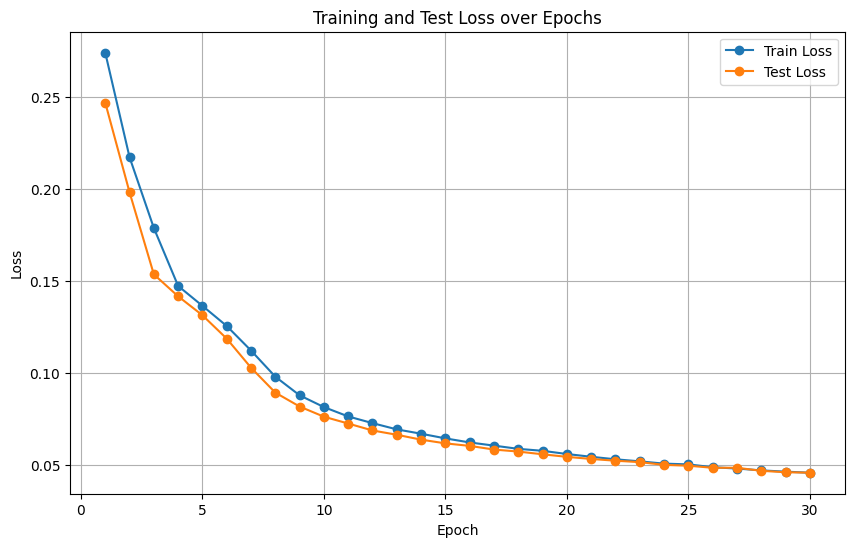

In [10]:
# ========== Plotting Loss ==========
plt.figure(figsize=(10,6))
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss',marker='o')
plt.plot(range(1, num_epochs+1), test_losses, label='Test Loss',marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()